In [1]:
import os
os.getcwd()

'C:\\Users'

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df=pd.read_csv('D:\work\Credit_Card_fraud_detection\creditcard.csv')

In [4]:
df.sample(5)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
60079,49147.0,-0.601555,1.055684,1.443927,0.714480,-0.103281,-0.425297,0.813901,-0.735988,0.425767,...,0.051522,0.618870,-0.145877,0.548129,-0.529885,0.437228,-0.769302,-0.445958,7.80,0
203446,134819.0,1.837937,-0.798216,-0.703395,0.406549,-0.538015,-0.086876,-0.506843,-0.026873,1.287217,...,0.212219,0.617436,-0.044378,-0.706899,-0.177389,0.652975,-0.040615,-0.039399,112.64,0
215126,139948.0,-1.443568,0.546939,0.268917,-1.179912,1.559546,-1.762901,1.478003,-0.603127,0.100783,...,0.149666,0.777923,-0.409748,-0.004212,0.667503,-0.307039,-0.118391,0.127621,43.16,0
270566,164144.0,1.951433,-0.406136,-0.058834,0.940052,-0.498295,0.630979,-1.103440,0.341465,1.093585,...,0.260417,0.800598,0.072977,-1.144417,-0.257445,-0.564161,0.077846,-0.037772,8.80,0
138636,82773.0,-1.358735,-0.458512,2.767805,-0.787113,-0.418307,-0.453053,-0.099751,0.203623,-0.764129,...,-0.300913,-0.627595,0.008569,0.301332,0.488296,-0.635334,0.040064,0.089135,73.52,0


This dataset presents transactions that occurred in two days, where we have 492 frauds out of 284,807 transactions. The dataset is highly unbalanced, the positive class (frauds) account for 0.172% of all transactions. (Details of dataset from sources of Kaggle)

It contains only numerical input variables which are the result of a PCA transformation. Unfortunately, due to confidentiality issues, we cannot provide the original features and more background information about the data. Features V1, V2, … V28 are the principal components obtained with PCA

In [5]:
df.shape

(284807, 31)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [7]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.759061e-12,-8.251130e-13,-9.654937e-13,8.321385e-13,1.649999e-13,4.248366e-13,-3.054600e-13,8.777971e-14,-1.179749e-12,...,-3.405756e-13,-5.723197e-13,-9.725856e-13,1.464150e-12,-6.987102e-13,-5.617874e-13,3.332082e-12,-3.518874e-12,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [8]:
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [ ]:
df['Class'].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

So from above output, we can see there are 492 Credit Card Frauds and 28,4315 normal transactions. Fraud datasets is highly imbalanced.

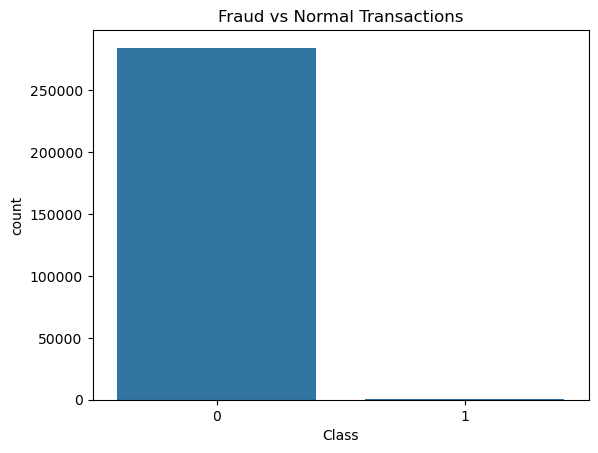

In [10]:
import seaborn as sns
sns.countplot(x='Class', data=df)
plt.title("Fraud vs Normal Transactions")
plt.show()

From above plot we can analyze:  
Class 0 → normal transactions (majority)  
Class 1 → fraud transactions (very few)

This confirms the imbalance in dataset

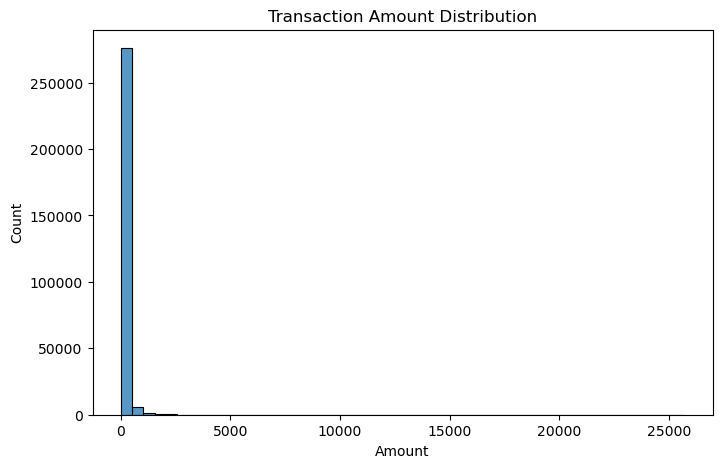

In [11]:
plt.figure(figsize=(8,5))
sns.histplot(df['Amount'], bins=50)
plt.title("Transaction Amount Distribution")
plt.show()

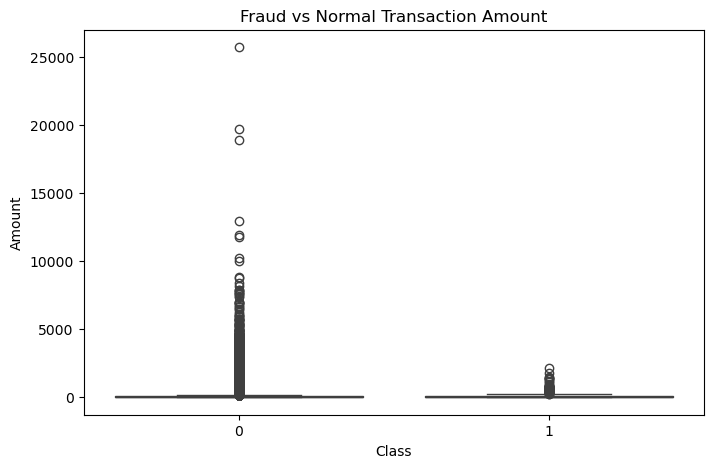

In [12]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Class', y='Amount', data=df)
plt.title("Fraud vs Normal Transaction Amount") 
plt.show()

In [13]:
X=df.drop('Class',axis=1)
y=df['Class']

In [14]:
df.sample(3)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
146985,88006.0,-1.327411,1.726510,-1.138969,-1.930347,1.959093,-0.780936,2.496802,-1.249270,1.785538,...,-0.328360,0.806667,-0.470716,-1.099227,-0.040944,-0.020198,-0.143399,-0.914802,7.68,0
17294,28606.0,1.292435,0.254692,-0.412428,0.115407,0.771845,0.726339,-0.088270,0.156918,-0.207628,...,-0.314718,-0.869951,-0.074836,-1.733542,0.365157,0.211753,-0.008564,0.001052,1.79,0
269787,163775.0,1.974680,-0.334727,-0.202017,0.525106,-0.744031,-0.603513,-0.530556,-0.121642,1.319781,...,0.205966,0.901164,0.108483,0.098626,-0.064999,-0.219070,0.048206,-0.034033,9.99,0


In [15]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
X['sc_time']=sc.fit_transform(X['Time'].values.reshape(-1,1))
X['sc_amt']=sc.fit_transform(X['Amount'].values.reshape(-1,1))

In [16]:
X=X.drop(['Time','Amount'],axis=1)

In [17]:
#now splitting the data into training & testing data
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
#stratify=y preserves fraud distribution properly

In [19]:
from imblearn.over_sampling import SMOTE
sm=SMOTE(random_state=42)
X_train_resamp, y_train_resamp = sm.fit_resample(X_train,y_train)

In [20]:
y_train_resamp.value_counts()

Class
0    227451
1    227451
Name: count, dtype: int64

In [21]:
y_train_resamp.value_counts()

Class
0    227451
1    227451
Name: count, dtype: int64

In [22]:
from sklearn.linear_model import LogisticRegression
model=LogisticRegression(max_iter=1000)
model.fit(X_train_resamp,y_train_resamp)

LogisticRegression(max_iter=1000)

Why Logistic Regression first?

- fast to train   
- interpretable   
- strong baseline for comparison   
- works well with scaled PCA features   

In [23]:
y_pred=model.predict(X_test)

In [24]:
y_pred_prob = model.predict_proba(X_test)[:,1]

In [25]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962



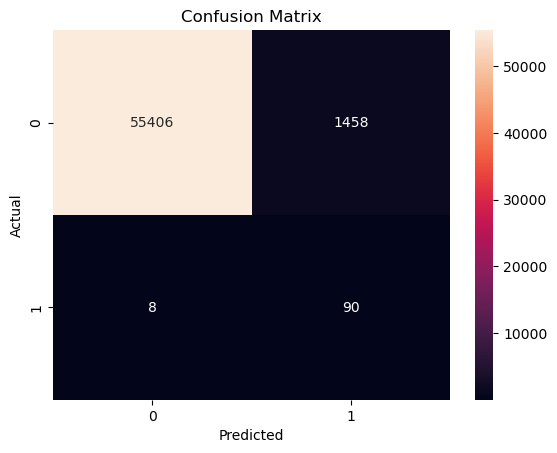

In [26]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Top-left → correct normal predictions   
Top-right → false alarms   
Bottom-left → missed fraud cases (critical)   
Bottom-right → correctly detected frauds   

In [ ]:
from sklearn.metrics import roc_auc_score
roc_auc_score(y_test, y_pred_prob)

np.float64(0.9698482164390798)

In [30]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=10,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_resamp, y_train_resamp)

RandomForestClassifier(n_estimators=10, n_jobs=-1, random_state=42)

In [31]:
y_pred_rf=rf_model.predict(X_test)
y_pred_prob_rf=rf_model.predict_proba(X_test)[:,1]

In [32]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.86      0.82      0.84        98

    accuracy                           1.00     56962
   macro avg       0.93      0.91      0.92     56962
weighted avg       1.00      1.00      1.00     56962



In [33]:
from sklearn.tree import DecisionTreeClassifier
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_resamp, y_train_resamp)

DecisionTreeClassifier(random_state=42)

In [34]:
y_pred_dt = dt_model.predict(X_test)
y_pred_prob_dt = dt_model.predict_proba(X_test)[:,1]

In [35]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.34      0.78      0.47        98

    accuracy                           1.00     56962
   macro avg       0.67      0.89      0.74     56962
weighted avg       1.00      1.00      1.00     56962



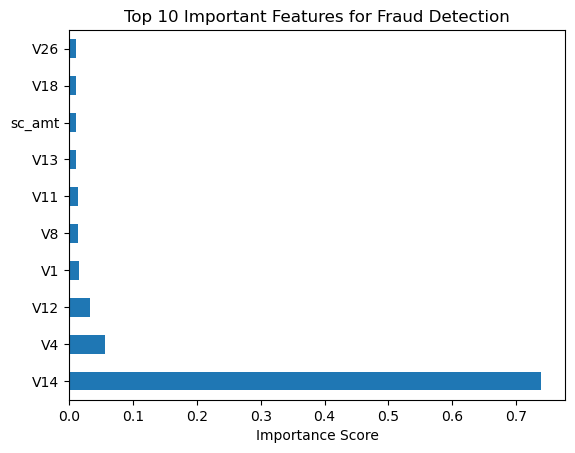

In [36]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importances = pd.Series(
    dt_model.feature_importances_,
    index=X_train.columns
)

top_features = feature_importances.sort_values(ascending=False).head(10)

top_features.plot(kind='barh')
plt.title("Top 10 Important Features for Fraud Detection")
plt.xlabel("Importance Score")
plt.show()

In [41]:
probability = dt_model.predict_proba(X_test)[0][1]

if probability >= 0.3:
    print("Fraudulent Transaction")
else:
    print("Normal Transaction")

Normal Transaction


In [44]:
y_probabilities = dt_model.predict_proba(X_test)[:,1]

results = X_test.copy()
results["Actual_Class"] = y_test
results["Fraud_Probability"] = y_probabilities

results.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V23,V24,V25,V26,V27,V28,sc_time,sc_amt,Actual_Class,Fraud_Probability
263020,-0.674466,1.408105,-1.110622,-1.328366,1.388996,-1.308439,1.885879,-0.614233,0.311652,0.650757,...,-0.224327,0.707899,-0.135837,0.045102,0.533837,0.291319,1.388689,-0.261273,0,0.0
11378,-2.829816,-2.765149,2.537793,-1.074580,2.842559,-2.153536,-1.795519,-0.250020,3.073504,-1.000418,...,-0.813272,0.042996,-0.027660,-0.910247,0.110802,-0.511938,-1.578646,-0.305852,0,0.0
147283,-3.576495,2.318422,1.306985,3.263665,1.127818,2.865246,1.444125,-0.718922,1.874046,7.398491,...,-0.132058,-1.483996,-0.296011,0.062823,0.552411,0.509764,-0.136621,-0.049095,0,0.0
219439,2.060386,-0.015382,-1.082544,0.386019,-0.024331,-1.074935,0.207792,-0.338140,0.455091,0.047859,...,0.331818,-0.067584,-0.283675,0.203529,-0.063621,-0.060077,0.988041,-0.349271,0,0.0
36939,1.209965,1.384303,-1.343531,1.763636,0.662351,-2.113384,0.854039,-0.475963,-0.629658,-1.579654,...,-0.154631,0.619449,0.818998,-0.330525,0.046884,0.104527,-1.180778,-0.347232,0,0.0


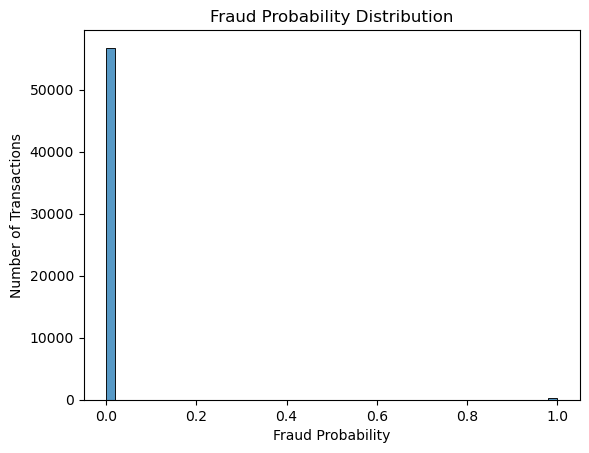

In [45]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(y_probabilities, bins=50)
plt.title("Fraud Probability Distribution")
plt.xlabel("Fraud Probability")
plt.ylabel("Number of Transactions")
plt.show()

In [46]:
threshold = 0.3

predicted_fraud = (y_probabilities >= threshold).astype(int)

sum(predicted_fraud)

np.int64(223)